# Computer Vision — Part 1 · Practical Notebook


**Companion lab for the lecture: Image Formation → Pixels & Color → Labels & Features → Frequency & Filters → Edges (Sobel, Canny) → Image Digitization → Transforms → Histogram Equalization**

---

This is the **classical computer vision** lab — everything that happens *before*
deep learning. No models are trained here. The goal is to genuinely understand
how an image is data, and how the classic image-processing operations actually
work, by implementing and using them.

**A note on tooling.** Part 1 uses **OpenCV (`cv2`) + NumPy**, not PyTorch. That
is a deliberate, real-world choice: classical CV — color conversion, blurring,
Sobel, Canny, histogram equalization — is done with OpenCV/NumPy in industry
every day. There is nothing to "train", so a deep-learning framework would be
the wrong tool. (PyTorch returns in Part 2, where we *do* train networks.)

To make the *why* stick, several operations are shown **twice**: once
implemented by hand with NumPy so you see the mechanics, then with the
one-line OpenCV call you would actually use in production.

> **How to run this:** anywhere with Python + `opencv-python`, `numpy`,
> `matplotlib`, `scikit-image`. Google Colab has all of these pre-installed.
> No GPU needed — this is all CPU work.


## 1 · Setup & loading an image

We import the classical-CV toolkit and load a test image. To keep this notebook
**fully offline and reproducible**, we use a sample image that ships with
`scikit-image` (no downloads). Everything you learn applies identically to your
own images loaded with `cv2.imread("path.jpg")`.


In [ ]:
# Optional: mount Google Drive for saving files (Colab only).
# If you're running locally (Jupyter / Kaggle / VS Code), this just no-ops.
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    print("Google Drive mounted at /content/drive")
except ImportError:
    print("Not on Colab -- skipping Drive mount. (Files will save to the working directory.)")


Mounted at /content/drive
Google Drive mounted at /content/drive


image shape : (512, 512, 3)   (height, width, channels)
dtype       : uint8  -- 8-bit, so pixel values are 0..255
value range : 0 to 255


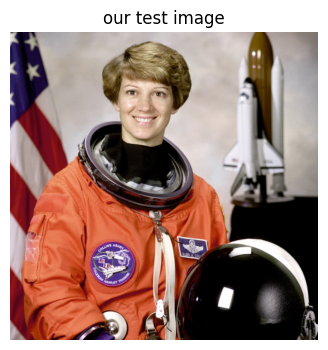

In [ ]:
# On a fresh environment you may need:  !pip install opencv-python scikit-image matplotlib numpy
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data   # ships with sample images -- keeps us 100% offline

np.random.seed(0)

# A real color photo that ships with scikit-image (no download needed).
img_rgb = data.astronaut()          # shape (512, 512, 3), RGB, uint8
# 2 ^ 8 = 256
print("image shape :", img_rgb.shape, "  (height, width, channels)")
print("dtype       :", img_rgb.dtype, " -- 8-bit, so pixel values are 0..255")
print("value range :", img_rgb.min(), "to", img_rgb.max())

plt.figure(figsize=(4, 4))
plt.imshow(img_rgb); plt.title("our test image"); plt.axis("off")
plt.show()


## 2 · Images as grids of numbers

> *Lecture recap:* a digital image is a **2D grid of pixels** (for grayscale).
> Each pixel has a location `(x, y)` and an intensity value. For an 8-bit
> grayscale image that value is **0 (black) to 255 (white)**, grey in between.
> The origin `(0, 0)` is the **top-left** corner. Treating images as grids of
> numbers is the basis of all image processing — you can brighten an image by
> multiplying every pixel, shift it, and so on.

Let's make this concrete. First, convert to grayscale and inspect actual pixel
values.


In [ ]:
# TODO -- convert the loaded RGB image to grayscale, then inspect a small
# pixel patch and one specific pixel to make "an image is just numbers" concrete.
#
# Steps:
#  1) Convert img_rgb to grayscale with cv2.cvtColor and the right flag.
#  2) Extract a 6x6 patch -- use slicing, e.g. gray[100:106, 100:106].
#  3) Look up the intensity at one pixel. REMEMBER: NumPy is array[row, col],
#     so gray[y, x] -- NOT gray[x, y]. This is a real bug source.

gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)     # convert to grayscale
print("grayscale shape:", gray.shape, " -- just (height, width), no channel axis")

# Extract a small patch as raw numbers
patch = gray[100:106, 100:106]                        # gray[100:106, 100:106]
print("\nA 6x6 patch of raw pixel values around (row=100, col=100):")
print(patch)

# Read one specific pixel
y, x = 200, 350
intensity = gray[y, x]                               # gray[y, x]
print(f"\nPixel at (x={x}, y={y}) has intensity:", intensity)


**The indexing trap:** the lecture talks about pixels at `(x, y)`, but NumPy
arrays are indexed `[row, column]` which is `[y, x]`. Mixing these up is one of
the most common beginner bugs. We'll be careful and always note it.

Now the lecture's claim — *"images are numbers, so we can just do math on them"*
— demonstrated:


In [ ]:
# TODO -- demonstrate the lecture's point: "images are numbers, you can do
# math on them". Build three transformations of `gray`:
#
#  - BRIGHTER:  multiply every pixel by 1.6 (clip to 0..255). USE the
#               overflow-safe pattern: cast to int32/float, multiply, np.clip,
#               cast back to uint8. Otherwise a uint8 200 * 1.6 wraps around.
#  - DARKER:    multiply every pixel by 0.4 (no clip needed for darkening).
#  - INVERTED:  255 - value.

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

axes[0].imshow(gray, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("original")

brighter = np.clip(gray.astype(np.float32) * 1.6, 0, 255).astype(np.uint8)  # safe brighten by 1.6
axes[1].imshow(brighter, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("x 1.6  (brighter)")

darker = (gray.astype(np.float32) * 0.4).astype(np.uint8)  # darken by 0.4
axes[2].imshow(darker, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("x 0.4  (darker)")

inverted = (255 - gray).astype(np.uint8)             # 255 - value
axes[3].imshow(inverted, cmap="gray", vmin=0, vmax=255)
axes[3].set_title("255 - value  (inverted)")

for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()


### TODO 2.1
Write a function `adjust(image, contrast, brightness)` that applies the standard
point operation `output = contrast * pixel + brightness`, **safely** (no uint8
overflow — clip to 0–255). Test it with `contrast=1.5, brightness=30` and
display the result next to the original.


In [ ]:
# TODO 2.1 -- implement a safe contrast/brightness adjustment.
# The point operation:  output = contrast * pixel + brightness
# It must be SAFE: a uint8 image overflows on 255 + 1 -> 0, so you have to:
#   1) cast to a wider numeric type (float32) so math doesn't wrap around
#   2) apply  contrast * pixel + brightness
#   3) clip to [0, 255]
#   4) cast back to uint8 and return

def adjust(image, contrast, brightness):
    out = np.clip(contrast * image.astype(np.float32) + brightness, 0, 255).astype(np.uint8)
    return out

# Sanity check: contrast 1.5, brightness +30 should noticeably brighten gray.
result = adjust(gray, contrast=1.5, brightness=30)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(gray,   cmap="gray", vmin=0, vmax=255); axes[0].set_title("original")
axes[1].imshow(result, cmap="gray", vmin=0, vmax=255); axes[1].set_title("contrast 1.5, brightness +30")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()


## 3 · Color images, channels & color spaces

> *Lecture recap:* a color image is a **3D cube** — width × height × **depth**,
> where depth is the number of **channels**. RGB images have depth 3 (a red, a
> green, and a blue 2D layer stacked). Color carries more information than
> grayscale (essential for tasks like telling a yellow lane line from a white
> one) but costs more memory. Beyond RGB there are other **color spaces**: HSV
> (hue, saturation, value) and HLS — useful because some channels are more
> robust to lighting changes than others.

Let's split the image into its three RGB channels and *see* them.


In [ ]:
# TODO -- split the RGB image into its three channels and display them.
# Hint: img_rgb has shape (H, W, 3). Slice on the last axis.

R, G, B = img_rgb[:,:,0], img_rgb[:,:,1], img_rgb[:,:,2]  # img_rgb[:,:,0], [:,:,1], [:,:,2]
print("each channel shape:", R.shape, " -- a 2D array of 0..255 values")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img_rgb);             axes[0].set_title("RGB (all 3 stacked)")
axes[1].imshow(R, cmap="Reds");      axes[1].set_title("Red channel")
axes[2].imshow(G, cmap="Greens");    axes[2].set_title("Green channel")
axes[3].imshow(B, cmap="Blues");     axes[3].set_title("Blue channel")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()
print("Bright spots in a channel = lots of that color there.")


### The BGR vs RGB gotcha — see it for yourself

The lecture treats color as "RGB", but **OpenCV stores images as BGR**. If you
load a file with `cv2.imread` and display it without converting, red and blue
are swapped. Here's the exact bug, and the fix:


In [ ]:
# TODO -- demonstrate the BGR vs RGB gotcha.
# Step 1: simulate what cv2.imread() would have given us: the same image but
#         with the channel axis reversed (RGB -> BGR). Hint: img_rgb[:, :, ::-1].
# Step 2: show the BGR image as if it were RGB -- this is the bug.
# Step 3: fix it by calling cv2.cvtColor with the right BGR2RGB flag.

img_bgr = img_rgb[:, :, ::-1]                       # reverse the channel axis

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
axes[0].imshow(img_rgb);   axes[0].set_title("correct (RGB)")
axes[1].imshow(img_bgr);   axes[1].set_title("BGR shown as if RGB\n(THE BUG: red/blue swapped)")

fixed = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)    # cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

axes[2].imshow(fixed);     axes[2].set_title("cv2.cvtColor(BGR2RGB)\n(fixed)")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()
print("Rule: after cv2.imread(), call cv2.cvtColor(img, cv2.COLOR_BGR2RGB) before plotting.")


### HSV — why a different color space helps with lighting

> *Lecture recap:* the **V (value)** channel varies the most under different
> lighting; the **H (hue)** channel stays fairly consistent in shadow or
> brightness. So if we rely on **H** and discard **V**, we can detect colored
> objects more reliably than in RGB. (HSV ranges in OpenCV: H is 0–179,
> S and V are 0–255.)


In [ ]:
# TODO -- convert img_rgb to HSV, then split it into H, S, V channels.
# OpenCV flag: cv2.COLOR_RGB2HSV
# Reminder: in OpenCV, H ranges 0-179, S and V range 0-255.

hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)      # convert RGB -> HSV
H, S, V = hsv[:,:,0], hsv[:,:,1], hsv[:,:,2]       # split the 3 channels

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img_rgb);            axes[0].set_title("original")
axes[1].imshow(H, cmap="hsv");      axes[1].set_title("H (hue) — robust to lighting")
axes[2].imshow(S, cmap="gray");     axes[2].set_title("S (saturation)")
axes[3].imshow(V, cmap="gray");     axes[3].set_title("V (value) — varies with lighting")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()


### TODO 3.1
The lecture poses a question: *to discriminate between cats and dogs, should you
use grayscale or RGB?* Answer it in a comment with your reasoning.

Then, code task: implement the lecture's **three RGB→grayscale methods** by hand
and display all three plus OpenCV's result:
- **Lightness:** `(max(R,G,B) + min(R,G,B)) / 2`
- **Average:** `(R + G + B) / 3`
- **Luminosity** (the best — matches human vision, which is most sensitive to
  green): `0.21*R + 0.72*G + 0.07*B`


In [ ]:
# TODO 3.1 -- implement the lecture's three RGB->grayscale methods by hand.
# Written answer: should you use grayscale or RGB to distinguish cats from
# dogs? Why? (Write your answer in this comment)
#   -> RGB is better. Cats and dogs often have distinct fur colors (orange tabby vs black lab)
#      that look identical in grayscale. Color channels carry discriminative information that
#      grayscale discards.

# Now the code: implement these three formulas. R, G, B are the channels (uint8).
# Promote to float32 first so the arithmetic doesn't overflow.
Rf = R.astype(np.float32); Gf = G.astype(np.float32); Bf = B.astype(np.float32)

lightness  = ((np.maximum(np.maximum(Rf, Gf), Bf) + np.minimum(np.minimum(Rf, Gf), Bf)) / 2).astype(np.uint8)  # (max(R,G,B) + min(R,G,B)) / 2
average    = ((Rf + Gf + Bf) / 3).astype(np.uint8)  # (R + G + B) / 3
luminosity = (0.21*Rf + 0.72*Gf + 0.07*Bf).astype(np.uint8)  # 0.21*R + 0.72*G + 0.07*B -- matches human vision
opencv_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

titles = ["lightness", "average", "luminosity (best)", "cv2 (also luminosity-based)"]
imgs   = [lightness, average, luminosity, opencv_gray]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, im, t in zip(axes, imgs, titles):
    ax.imshow(np.clip(im, 0, 255).astype(np.uint8), cmap="gray", vmin=0, vmax=255)
    ax.set_title(t); ax.axis("off")
plt.tight_layout(); plt.show()


## 4 · Color thresholding — selecting an area of interest

> *Lecture recap:* a **color threshold** isolates a region by keeping only
> pixels whose color falls in a chosen range — the classic example is a
> **blue/green screen**, where you detect a large consistent colored area and
> replace it. The catch: a plain RGB threshold breaks under changing light
> (shadows, glare). Doing the threshold in **HSV** is more robust because hue is
> stable under lighting changes.

We'll build a synthetic "green screen" scene (a colored subject on a green
background) so the lesson is crystal-clear and fully offline, then key out the
green.


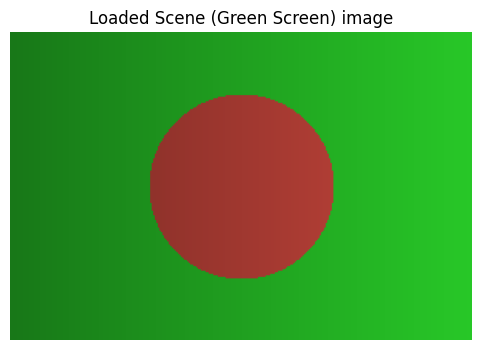

Scene image loaded from /content/drive/MyDrive/Computer_Vision/Lec1/scene_green_screen.png


In [ ]:
import cv2

# Define the path to load the scene image from Google Drive
scene_load_path = '/content/drive/MyDrive/Computer_Vision/Lec1/scene_green_screen.png'

# Load the scene image
scene = cv2.imread(scene_load_path)

# OpenCV loads images as BGR, so convert to RGB for correct display with matplotlib
scene = cv2.cvtColor(scene, cv2.COLOR_BGR2RGB)

# Display the loaded image to verify
plt.figure(figsize=(6, 4))
plt.imshow(scene)
plt.title('Loaded Scene (Green Screen) image')
plt.axis('off')
plt.show()
print(f'Scene image loaded from {scene_load_path}')

In [ ]:
# TODO -- chroma-key (green-screen) the loaded `scene`.
# Steps:
#  1) Convert scene to HSV.
#  2) Build a binary mask of "green" pixels using cv2.inRange. Green in OpenCV
#     HSV is roughly H in [35, 85], S/V both >= 40.
#  3) INVERT the mask -- you want to KEEP the subject (everything that's NOT
#     green). Use cv2.bitwise_not.
#  4) Build a navy background (np.full_like) and composite the subject onto it
#     using np.where: keep `scene` where subject_mask is 255, else use bg.

scene_hsv = cv2.cvtColor(scene, cv2.COLOR_RGB2HSV)        # cvtColor RGB->HSV
lower_green = np.array([35, 40, 40])
upper_green = np.array([85, 255, 255])
green_mask = cv2.inRange(scene_hsv, lower_green, upper_green)  # cv2.inRange
subject_mask = cv2.bitwise_not(green_mask)                # invert with cv2.bitwise_not

new_bg = np.full_like(scene, (30, 30, 120))                # a navy background
keyed = np.where(subject_mask[:, :, None] == 255, scene, new_bg)  # np.where(...)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.4))
axes[0].imshow(scene);                     axes[0].set_title("scene (green screen)")
axes[1].imshow(green_mask, cmap="gray");   axes[1].set_title("green mask")
axes[2].imshow(subject_mask, cmap="gray"); axes[2].set_title("subject mask (inverted)")
axes[3].imshow(keyed);                     axes[3].set_title("composited onto new bg")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()


### TODO 4.1
The green key above used a fixed HSV range. Your task: turn it into a small
**interactive-style experiment**. Write a function
`key_out(scene, lower, upper)` that returns the composited image, then call it
with **three different** `lower`/`upper` green ranges — one too narrow (green
leaks through), one too wide (it eats part of the subject), and one good. Display
all three and label which is which.


In [ ]:
# TODO 4.1 -- experiment with HSV threshold ranges.
# The function below implements the chroma key: build a green mask in HSV,
# invert it to get the subject, composite onto a navy background.
def key_out(scene, lower, upper):
    hsv  = cv2.cvtColor(scene, cv2.COLOR_RGB2HSV)
    mask = cv2.inRange(hsv, np.array(lower), np.array(upper))
    subject = cv2.bitwise_not(mask)
    bg = np.full_like(scene, (30, 30, 120))
    return np.where(subject[:, :, None] == 255, scene, bg)

# Pick THREE (lower, upper) green ranges that demonstrate three failure modes:
#  - "too narrow":  the range catches only the brightest green, so darker green
#                   shadows leak through (mask too small).
#  - "too wide":    the range eats into the SUBJECT's colors, mask too big.
#  - "just right":  catches all green without touching the subject.
# Remember HSV in OpenCV: H is 0-179, S and V are 0-255. Green hue ~ 35-85.
ranges = [
    ("too narrow", [55, 150, 150], [75, 255, 255]),
    ("too wide",   [20,  20,  20],  [110, 255, 255]),
    ("just right", [35, 40, 40],    [85, 255, 255]),
]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, (label, lo, hi) in zip(axes, ranges):
    ax.imshow(key_out(scene, lo, hi)); ax.set_title(label); ax.axis("off")
plt.tight_layout(); plt.show()


## 5 · Morphological operations — cleaning up binary masks

The thresholding in Section 4 produced a binary mask, but real-world masks are
*never* clean: they have stray bright pixels in the "off" region, tiny dark
holes inside the "on" region, and jagged edges. **Morphological operations**
fix all of these with a tiny, fast toolkit:

- **Erosion** — shrinks the white region by one pixel layer. Kills isolated
  bright noise pixels; thins narrow connections.
- **Dilation** — grows the white region by one pixel layer. Fills small dark
  holes; thickens narrow lines and connections.
- **Opening** = **erosion then dilation**. Removes small bright noise specks
  *without* shrinking real objects (the erosion deletes them, the dilation
  restores object size).
- **Closing** = **dilation then erosion**. Fills small dark holes *without*
  growing real objects.

These are pure pixel operations — no learning, no parameters except the
**structuring element** (a small kernel, usually 3×3 or 5×5). They're used in
nearly every classical-CV pipeline that produces a binary mask: medical
segmentation, document scanning, manufacturing defect detection, motion
detection.


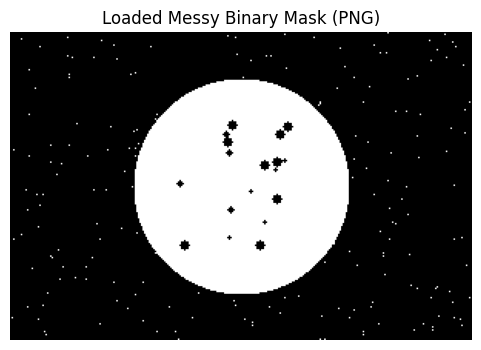

Messy binary mask loaded from /content/drive/MyDrive/Computer_Vision/Lec1/messy_mask.png


In [ ]:
import cv2

# Define the path to load the messy binary mask from Google Drive
messy_mask_load_path = '/content/drive/MyDrive/Computer_Vision/Lec1/messy_mask.png'

# Load the mask back from Google Drive as grayscale
mask = cv2.imread(messy_mask_load_path, cv2.IMREAD_GRAYSCALE)

# Display the loaded image to verify
plt.figure(figsize=(6, 4))
plt.imshow(mask, cmap='gray')
plt.title('Loaded Messy Binary Mask (PNG)')
plt.axis('off')
plt.show()
print(f'Messy binary mask loaded from {messy_mask_load_path}')

### Erosion and dilation — the two atoms

The structuring element decides the shape and reach of the operation. A 3×3
square is the most common; bigger means more aggressive. **Erosion** keeps a
pixel white only if *all* pixels under the kernel are white; **dilation** turns
a pixel white if *any* pixel under the kernel is white.


In [ ]:
# TODO -- the two morphology atoms: erosion and dilation.
# Build a 3x3 SQUARE structuring element with cv2.getStructuringElement,
# then apply cv2.erode and cv2.dilate to `mask` with iterations=1.
# Read the trade-off off the result:
#   - erode kills isolated bright pixels (salt) but ALSO shrinks the disk
#   - dilate fills small dark holes (pepper) but ALSO grows the disk

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))  # 3x3 MORPH_RECT
print("3x3 structuring element:")
print(kernel)

eroded  = cv2.erode(mask, kernel, iterations=1)      # cv2.erode
dilated = cv2.dilate(mask, kernel, iterations=1)     # cv2.dilate

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(mask,    cmap="gray"); axes[0].set_title("original mask")
axes[1].imshow(eroded,  cmap="gray"); axes[1].set_title("erode (kills salt; shrinks disk)")
axes[2].imshow(dilated, cmap="gray"); axes[2].set_title("dilate (fills pepper; grows disk)")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()


Notice the trade-off: **erosion** killed the salt noise but also shrank
the real disk. **Dilation** filled the holes but also grew the disk and
worsened the salt (each speck became a 3×3 patch). Neither alone is what we
want. The fix is to **chain them** — that's opening and closing.

### Opening and closing — the workhorses

- **Opening** (erode → dilate): salt-killer that *preserves object size*.
- **Closing** (dilate → erode): hole-filler that *preserves object size*.

Real pipelines often run **both** in sequence to clean a noisy mask completely.


In [ ]:
# TODO -- opening and closing (the workhorses).
# OPENING  = erode -> dilate (kills bright noise WITHOUT shrinking the object)
# CLOSING  = dilate -> erode (fills holes WITHOUT growing the object)
# Use cv2.morphologyEx with cv2.MORPH_OPEN and cv2.MORPH_CLOSE.
# `kernel` is still the 3x3 element from the previous cell.

opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel)  # cv2.morphologyEx(... MORPH_OPEN ...)
closed = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)  # cv2.morphologyEx(... MORPH_CLOSE ...)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(mask,   cmap="gray"); axes[0].set_title("original (messy)")
axes[1].imshow(opened, cmap="gray"); axes[1].set_title("OPEN: salt gone, disk same size")
axes[2].imshow(closed, cmap="gray"); axes[2].set_title("CLOSE: holes filled, disk same size")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

# Now the complete cleanup: OPEN then CLOSE (apply both in sequence).
clean = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)  # MORPH_CLOSE on `opened`
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(mask,  cmap="gray"); axes[0].set_title("original")
axes[1].imshow(clean, cmap="gray"); axes[1].set_title("open + close (fully cleaned)")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()


### A real-world example — cleaning the green-screen mask from Section 4

The chroma-key mask we built in Section 4 had ragged edges and small holes.
Morphology cleans it in two lines:


In [ ]:
# TODO -- clean the chroma-key mask from Section 4 with a 5x5 ELLIPSE kernel.
# Steps:
#  1) Threshold the `scene` in HSV again -- but this time INVERT the green
#     mask so `raw_mask` is white on the SUBJECT (not the background).
#  2) Build a 5x5 ELLIPSE structuring element.
#  3) Apply OPEN (kills speckles in the white subject region), then CLOSE
#     (fills holes inside the subject), in sequence.

hsv = cv2.cvtColor(scene, cv2.COLOR_RGB2HSV)
raw_mask = cv2.bitwise_not(cv2.inRange(hsv, np.array([35, 40, 40]), np.array([85, 255, 255])))  # cv2.bitwise_not(cv2.inRange(...))

k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))  # 5x5 MORPH_ELLIPSE
cleaned = cv2.morphologyEx(raw_mask, cv2.MORPH_OPEN,  k)  # OPEN
cleaned = cv2.morphologyEx(cleaned,  cv2.MORPH_CLOSE, k)  # then CLOSE

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
axes[0].imshow(scene);                axes[0].set_title("scene")
axes[1].imshow(raw_mask, cmap="gray"); axes[1].set_title("raw threshold mask (ragged)")
axes[2].imshow(cleaned,  cmap="gray"); axes[2].set_title("after open + close")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()
print("This open->close cleanup is one of the most common patterns in classical CV.")


### TODO 5.1
You're processing a scanned document. The binary mask of the text has:
- **Stray dark specks** in the white paper background (dust on the scanner).
- **Small gaps inside thick letter strokes** (the scanner missed pixels).

(Note: in document scanning, *text* is usually **black on white**, so the
"object" is the dark region — the roles of erosion/dilation/open/close are
**flipped** from our disk example. This is the realistic situation.)

For each problem, pick the right operation (`erode`, `dilate`, `open`, or
`close`) and explain in one line **why**. Then chain them into a `clean_text`
function.


In [ ]:
# TODO 5.1 -- text-cleaning order.
# Scenario: black text on white paper. The TEXT is the dark region.
#  - Dark specks in the WHITE background (scanner dust): "salt" on the
#    background.
#  - Small gaps inside DARK strokes (scanner skipped pixels): "pepper" inside
#    the text.
# Pick the right morphological operation (cv2.MORPH_OPEN, cv2.MORPH_CLOSE,
# cv2.MORPH_ERODE, cv2.MORPH_DILATE) for each step.
#
# Hint: when the OBJECT is dark, the roles of open and close swap. The names
# "open" and "close" are anchored to the WHITE region.
#   * OPEN  shrinks white, then grows it back -> kills bright specks in white
#   * CLOSE grows white, then shrinks it -> fills dark holes inside white
# Flip the meaning when YOUR object is the dark region.

def clean_text(text_mask, ksize=3):
    k = cv2.getStructuringElement(cv2.MORPH_RECT, (ksize, ksize))
    # Step 1: remove dark specks from the white background
    step1 = cv2.morphologyEx(text_mask, cv2.MORPH_CLOSE, k)
    # Step 2: fill small gaps inside the dark strokes
    step2 = cv2.morphologyEx(step1,     cv2.MORPH_OPEN,  k)
    return step2

# Written answer (in this comment): why did you pick each operation?
#   - Step 1 (specks in background): MORPH_CLOSE -- grows white then shrinks it, filling dark specks in the white background
#   - Step 2 (gaps inside strokes):  MORPH_OPEN  -- shrinks white then grows it back, removing small white gaps inside dark strokes


## 6 · High-pass filters & convolution from scratch

> *Lecture recap:* **high-pass filters** enhance high-frequency content — edges,
> where neighbouring pixels change rapidly. A filter is a small matrix (a
> **convolution kernel**). **Kernel convolution** slides the kernel over the
> image, and at each pixel multiplies the kernel by the surrounding patch and
> sums — producing one output pixel. For an **edge-detection kernel the weights
> must sum to zero**, because the filter computes a *difference*; if they didn't
> sum to zero it would brighten or darken the whole image. At the borders, where
> the kernel hangs off the image, you must choose an **edge-handling** strategy:
> extend, pad with zeros, or crop.

This is the one operation in Part 1 worth implementing **by hand** — it's the
literal basis of convolutional neural networks. Let's write it.


In [ ]:
# TODO -- build the lecture's 3x3 high-pass (edge-detection) kernel.
# Center = +4, the 4-neighbours = -1, the 4 corners = 0.
# Note: the kernel weights MUST sum to 0 for an edge detector -- otherwise
# the filter brightens or darkens the whole image uniformly.

edge_kernel = np.array([[ 0, -1,  0],
                         [-1,  4, -1],
                         [ 0, -1,  0]], dtype=np.float32)  # 3x3 Laplacian-style edge kernel
print("edge kernel:\n", edge_kernel)
print("sum of weights:", edge_kernel.sum(), " <- MUST be 0 for an edge detector")

# We'll display alongside the original. The actual filtering happens in the
# next cell using cv2.filter2D.
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(gray,  cmap="gray");                 axes[0].set_title("original")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()


**Verify it against OpenCV** — our hand-written version should match the
library's optimized `cv2.filter2D`:


In [ ]:
# TODO -- apply the edge kernel using cv2.filter2D with 'extend' (replicate)
# border handling. The output is float -- display its absolute value.
edges_cv = cv2.filter2D(gray.astype(np.float32), -1, edge_kernel, borderType=cv2.BORDER_REPLICATE)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(np.abs(edges_cv), cmap="gray"); axes[0].set_title("cv2.filter2D (fast, for real use)")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()


## 7 · Gradients & the Sobel operator

> *Lecture recap:* a **gradient** measures intensity change — think of the image
> as a function `F(x, y)` and the gradient as its derivative. The **Sobel
> operator** uses **two kernels**: one approximates the gradient in **x**
> (horizontal change), one in **y** (vertical change). Convolving gives `Gx` and
> `Gy`; then **magnitude = √(Gx² + Gy²)** (large magnitude → likely an edge) and
> **direction = atan(Gy / Gx)**.

We define `convolve2d` below (from the lecture's convolution material in
Section 6) and use it to build Sobel from the two kernels.


In [ ]:
# TODO -- the Sobel gradients.
# A from-scratch `convolve2d` is provided so you can see exactly how a
# convolution slides a kernel over an image. Then we'll apply the two Sobel
# kernels to a slightly-smoothed grayscale image and combine them into a
# gradient magnitude and direction.

def convolve2d(image, kernel, edge='extend'):
    """A teaching-grade 2D convolution. In real code use cv2.filter2D."""
    kh, kw = kernel.shape
    ih, iw = image.shape
    pad_h, pad_w = kh // 2, kw // 2
    if edge == 'extend':
        padded_image = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='edge')
    elif edge == 'zero':
        padded_image = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    else:
        raise ValueError(f"Unsupported edge handling mode: {edge}")
    output = np.zeros_like(image, dtype=np.float32)
    for y in range(ih):
        for x in range(iw):
            roi = padded_image[y:y+kh, x:x+kw]
            output[y, x] = (roi * kernel).sum()
    return output

# Build the two Sobel kernels exactly as in the lecture (3x3, float32).
# sobel_x detects VERTICAL edges (large response on left-right intensity changes).
# sobel_y detects HORIZONTAL edges (large response on top-bottom intensity changes).
sobel_x = np.array([[-1, 0, 1],
                     [-2, 0, 2],
                     [-1, 0, 1]], dtype=np.float32)  # 3x3 np.array (vertical-edge detector)
sobel_y = np.array([[-1, -2, -1],
                     [ 0,  0,  0],
                     [ 1,  2,  1]], dtype=np.float32)  # 3x3 np.array (horizontal-edge detector)

# Smooth a touch first so we detect real edges, not pixel noise.
gray_smooth = cv2.GaussianBlur(gray, (3, 3), 0).astype(np.float32)

# Apply each kernel and combine.
Gx = convolve2d(gray_smooth, sobel_x, edge="extend")  # convolve2d(gray_smooth, sobel_x, edge="extend")
Gy = convolve2d(gray_smooth, sobel_y, edge="extend")  # convolve2d(gray_smooth, sobel_y, edge="extend")

magnitude = np.sqrt(Gx**2 + Gy**2)                   # sqrt(Gx^2 + Gy^2)
direction = np.arctan2(Gy, Gx)                       # atan2(Gy, Gx)  -- np.arctan2

fig, axes = plt.subplots(1, 4, figsize=(17, 4))
axes[0].imshow(Gx, cmap="gray");           axes[0].set_title("Gx (vertical edges)")
axes[1].imshow(Gy, cmap="gray");           axes[1].set_title("Gy (horizontal edges)")
axes[2].imshow(magnitude, cmap="gray");    axes[2].set_title("magnitude = sqrt(Gx^2+Gy^2)")
axes[3].imshow(direction, cmap="twilight");axes[3].set_title("direction = atan2(Gy, Gx)")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()


In [ ]:
# TODO -- verify your from-scratch Sobel against OpenCV's built-in cv2.Sobel.
# Use ksize=3, output type cv2.CV_32F.
gx_cv = cv2.Sobel(gray_smooth, cv2.CV_32F, 1, 0, ksize=3)
gy_cv = cv2.Sobel(gray_smooth, cv2.CV_32F, 0, 1, ksize=3)
mag_cv = np.sqrt(gx_cv**2 + gy_cv**2)                # sqrt(gx_cv^2 + gy_cv^2)

print(f"max difference, our Gx vs cv2.Sobel: {np.abs(Gx - gx_cv).max():.4f}")
print("(should be small -- our from-scratch Sobel matches cv2)")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(magnitude, cmap="gray"); axes[0].set_title("ours (convolve2d + sobel kernels)")
axes[1].imshow(mag_cv,    cmap="gray"); axes[1].set_title("cv2.Sobel")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()


### TODO 7.1
The Sobel magnitude gives a *continuous* edge strength. To get a clean **binary
edge map** you **threshold** it: pixels above some value become edges (white),
the rest become background (black).

Write `edge_map(magnitude, threshold)` returning a binary `uint8` image, and
display the result for **three** thresholds (low, medium, high). Describe the
trade-off: what does a too-low threshold give you? A too-high one?


In [ ]:
# TODO 7.1 -- threshold the Sobel magnitude into a binary edge map.
# `magnitude` is the per-pixel float gradient magnitude from the previous cell.
# Build a UINT8 binary image: pixels become 255 where magnitude > threshold,
# else 0.

def edge_map(magnitude, threshold):
    return (magnitude > threshold).astype(np.uint8) * 255

# The right thresholds depend on the magnitude range -- print it first.
print("magnitude range:", magnitude.min(), "to", magnitude.max())

# Pick THREE thresholds that demonstrate the trade-off:
#   - LOW  threshold -> lots of edges (and lots of noise)
#   - MED  threshold -> the sweet spot (cleanest edges)
#   - HIGH threshold -> only the strongest edges (you lose real but faint ones)
thresholds = [30, 80, 150]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, t in zip(axes, thresholds):
    ax.imshow(edge_map(magnitude, t), cmap="gray")
    ax.set_title(f"threshold = {t}")
    ax.axis("off")
plt.tight_layout(); plt.show()

# Describe the trade-off in this comment:
#  - too LOW threshold  -> many edges detected including noise; hard to identify real structure
#  - too HIGH threshold -> only the strongest edges survive; faint but real edges (fine textures) are lost


## 8 · Low-pass filters — averaging & Gaussian blur

> *Lecture recap:* **noise** (speckles, discoloration) carries no useful
> information and can be amplified by high-pass filters. **Low-pass filters**
> block high-frequency content — they **blur/smooth** the image and reduce
> noise. The simplest is the **averaging filter**: a 3×3 kernel of equal
> weights. Unlike a high-pass filter, a low-pass filter's weights **must sum to
> one** (so overall brightness is preserved) — the 3×3 box of ones sums to 9,
> so you **normalize by dividing by 9**. **Gaussian blur** is the most-used
> low-pass filter: a *weighted* average giving the most weight to the centre
> pixel and less to pixels further away. It blurs while preserving edges better
> than a plain box average.

Let's add salt-and-pepper noise (like the lecture's brain-scan example) and
clean it up.


In [ ]:
import cv2

# Define the path to load the noisy image from Google Drive
noisy_image_path = '/content/drive/MyDrive/Computer_Vision/Lec1/noisy_gray.png'

# Load the noisy image as grayscale
noisy = cv2.imread(noisy_image_path, cv2.IMREAD_GRAYSCALE)

# Check if the image was loaded successfully
if noisy is None:
    print(f"Error: Could not load image from {noisy_image_path}")
else:
    print(f'Noisy image loaded from {noisy_image_path}')

    # Display the loaded image to verify
    plt.figure(figsize=(6, 4))
    plt.imshow(noisy, cmap='gray', vmin=0, vmax=255)
    plt.title('Loaded Noisy Image')
    plt.axis('off')
    plt.show()

In [ ]:
box_kernel = np.ones((3, 3), dtype=np.float32) / 9   # 3x3 ones / 9
print("box kernel sum:", box_kernel.sum(), " <- MUST be 1 for a low-pass filter")

averaged = convolve2d(noisy.astype(np.float32), box_kernel, edge="extend")  # convolve2d(noisy, box_kernel, edge="extend")
gaussian = cv2.GaussianBlur(noisy, (5, 5), sigmaX=1.0)  # cv2.GaussianBlur(noisy, (5,5), sigmaX=1.0)

fig, axes = plt.subplots(1, 4, figsize=(17, 4.2))
axes[0].imshow(gray,     cmap="gray", vmin=0, vmax=255); axes[0].set_title("clean original")
axes[1].imshow(noisy,    cmap="gray", vmin=0, vmax=255); axes[1].set_title("+ salt & pepper noise")
axes[2].imshow(averaged, cmap="gray", vmin=0, vmax=255); axes[2].set_title("3x3 averaging filter")
axes[3].imshow(gaussian, cmap="gray", vmin=0, vmax=255); axes[3].set_title("Gaussian blur (5x5)")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()


Both blurs reduce the noise. But for salt-and-pepper noise specifically,
there's a *much* better classical tool — the **median filter** — and it's worth
seeing because it makes a real point about choosing the right filter for the
right noise:


In [ ]:
# TODO -- compare median filter to Gaussian on the same noisy image.
# The median filter is a NONLINEAR filter (no kernel weights -- it picks the
# median value in a window). Use cv2.medianBlur with kernel size 3.
median = cv2.medianBlur(noisy, 3)                    # cv2.medianBlur(noisy, 3)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
axes[0].imshow(noisy,    cmap="gray", vmin=0, vmax=255); axes[0].set_title("noisy")
axes[1].imshow(gaussian, cmap="gray", vmin=0, vmax=255); axes[1].set_title("Gaussian — blurs noise AND edges")
axes[2].imshow(median,   cmap="gray", vmin=0, vmax=255); axes[2].set_title("Median — kills speckles, keeps edges")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()
print("Median filter removes salt & pepper almost perfectly because a single")
print("extreme pixel can't survive a median. The 'right filter' depends on the noise.")


## 9 · The Canny edge detector, step by step

> *Lecture recap:* even with high- and low-pass filters, edge detection is hard
> — what intensity change counts as an edge? how do you get *thin* edges? The
> **Canny edge detector** is the classic, widely-used answer. Its steps:
> 1. **Gaussian blur** to remove noise (Section 8).
> 2. **Sobel gradients** → magnitude and direction (Section 7).
> 3. **Non-maximum suppression** — thin thick edges by keeping a pixel only if
>    it's the local maximum *along the gradient direction*.
> 4. **Hysteresis (double threshold)** — a high threshold marks *strong* edges;
>    a low threshold marks *weak* edges; a weak edge is kept **only if it
>    connects to a strong edge**, otherwise discarded.
>
> Notice Canny *reuses* everything you've already built in Sections 6, 7, and 8 —
> that's why it comes last.

First, watch it work as a single call (the real-world way), sweeping the two
thresholds:


In [ ]:
# TODO -- run Canny with THREE different (low, high) hysteresis-threshold pairs
# on `gray`. The typical rule of thumb: high:low ratio ~ 2:1 to 3:1.
# Try one low pair, one medium pair, one high pair so you can SEE the trade-off.
fig, axes = plt.subplots(1, 4, figsize=(17, 4.2))
axes[0].imshow(gray, cmap="gray"); axes[0].set_title("original"); axes[0].axis("off")

threshold_pairs = [(50, 100), (100, 200), (150, 300)]  # low, medium, high pairs
for ax, (lo, hi) in zip(axes[1:], threshold_pairs):
    edges = cv2.Canny(gray, lo, hi)                  # cv2.Canny(gray, lo, hi)
    ax.imshow(edges, cmap="gray")
    ax.set_title(f"cv2.Canny(low={lo}, high={hi})")
    ax.axis("off")

plt.tight_layout(); plt.show()
print("Lower thresholds -> more edges (and more noise). Higher -> only strong edges.")
print("The classic rule of thumb: high:low ratio of about 2:1 or 3:1.")


### TODO 9.1
You've now seen the **same `gray` image** processed by: a raw Sobel threshold
(Section 7), and Canny (this section). Put them side by side and write a short
comparison:
1. Display: Sobel-magnitude thresholded into a binary map **vs** `cv2.Canny`.
2. In a comment, name **two concrete things Canny does better** than the plain
   Sobel threshold, tying each to a specific Canny step.


In [ ]:
# TODO 9.1 -- Sobel-threshold vs Canny, side by side.
# Reuse `magnitude` from Section 7 and `edge_map` from TODO 7.1.

# Pick a threshold for the Sobel binary map (anything reasonable in the range
# you printed in TODO 7.1).
sobel_binary = edge_map(magnitude, threshold=80)
canny_binary = cv2.Canny(gray, 50, 150)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(sobel_binary, cmap="gray"); axes[0].set_title("Sobel magnitude, thresholded")
axes[1].imshow(canny_binary, cmap="gray"); axes[1].set_title("cv2.Canny")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

# Written answer: name TWO things Canny does better than a single-threshold
# Sobel binary map, and tie each to a specific Canny step (Gaussian blur,
# Sobel gradients, non-max suppression, hysteresis).
#  1) Non-maximum suppression: Canny thins edges to single-pixel width; plain Sobel thresholding
#     produces thick blobs wherever the gradient magnitude exceeds the cutoff.
#  2) Hysteresis (double threshold): Canny discards weak isolated edges (noise) unless they
#     connect to a strong edge; a single Sobel threshold keeps every pixel above the cutoff
#     regardless of whether it is noise or a real edge.


## 10 · Coordinate transformations — translate, rotate, scale

> *Lecture recap:* a **coordinate transformation** changes the spatial
> arrangement of pixels — by changing their coordinates. The basic types:
> **translation** (shift every pixel along x/y), **rotation** (turn around a
> centre point by an angle), and **scaling** (resize by stretching/shrinking).
> These are essential for image alignment, registration, and manipulation — and,
> as you'll see in Part 2, they're also the basis of data augmentation.

OpenCV does these with **2×3 transformation matrices** fed to `cv2.warpAffine`.


In [ ]:
# TODO -- the three core coordinate transformations.
# All three end with cv2.warpAffine. The DIFFERENCE is the 2x3 affine matrix
# you build:
#   Translation: M = [[1, 0, tx], [0, 1, ty]]
#   Rotation:    cv2.getRotationMatrix2D(center, angle, scale)
#   Scaling:     cv2.resize (or a scale matrix)

h, w = gray.shape

# --- TRANSLATION: shift right 80 px, down 40 px ---
M_translate = np.float32([[1, 0, 80], [0, 1, 40]])   # np.float32 2x3 with tx=80, ty=40
translated = cv2.warpAffine(gray, M_translate, (w, h))  # cv2.warpAffine(gray, M_translate, (w, h))

# --- ROTATION: 30 degrees CCW around the image centre ---
M_rotate = cv2.getRotationMatrix2D(center=(w//2, h//2), angle=30, scale=1.0)  # rotation matrix
rotated = cv2.warpAffine(gray, M_rotate, (w, h))     # cv2.warpAffine(gray, M_rotate, (w, h))

# --- SCALING: 50% size ---
scaled = cv2.resize(gray, (w//2, h//2), interpolation=cv2.INTER_AREA)  # 50% scale

fig, axes = plt.subplots(1, 4, figsize=(17, 4.2))
axes[0].imshow(gray,       cmap="gray"); axes[0].set_title(f"original  {gray.shape}")
axes[1].imshow(translated, cmap="gray"); axes[1].set_title("translated (+80, +40)")
axes[2].imshow(rotated,    cmap="gray"); axes[2].set_title("rotated 30 deg")
axes[3].imshow(scaled,     cmap="gray"); axes[3].set_title(f"scaled 50%  {scaled.shape}")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()
print("Note the black regions: after translation/rotation, some output pixels")
print("map to 'outside the original image' -- they get filled with 0 (black).")


### TODO 10.1
Transformations **compose**: you can combine them by multiplying their matrices.
Your task: produce an image that is **rotated 45° AND scaled to 70%** in one
`warpAffine` call.

`cv2.getRotationMatrix2D` actually takes a `scale` argument directly — so this
is achievable in one line. Do that, then *also* think about: if you did rotation
and translation as two separate `warpAffine` calls, would the order matter?
Answer in a comment.


In [ ]:
# TODO 10.1 -- rotate 45 degrees AND scale to 70%, in ONE call to warpAffine.
# Hint: cv2.getRotationMatrix2D takes a `scale` argument, so this is achievable
# in a single line without composing two matrices.
h, w = gray.shape

M = cv2.getRotationMatrix2D(center=(w//2, h//2), angle=45, scale=0.7)
rot_and_scaled = cv2.warpAffine(gray, M, (w, h))

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(gray,           cmap="gray"); axes[0].set_title("original")
axes[1].imshow(rot_and_scaled, cmap="gray"); axes[1].set_title("rotated 45 deg + scaled 70%")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

# Written answer: if you did ROTATION and TRANSLATION as TWO separate steps,
# would the order (rotate-then-translate vs translate-then-rotate) matter? Why?
#  -> Yes, the order matters. Rotate-then-translate pivots around the original centre then shifts.
#     Translate-then-rotate shifts the pivot first, so the rotation happens around a different point.
#     In matrix terms: R*T != T*R -- matrix multiplication is not commutative.


## 11 · Histograms & histogram equalization

> *Lecture recap:* an image **histogram** plots, for each intensity value (x-axis
> 0–255), how many pixels have it (y-axis). The *shape* tells you about contrast:
> a **narrow** histogram clustered in the middle = **low contrast**; a histogram
> **spread across the whole range** = **high contrast**. **Histogram
> equalization** improves contrast by **redistributing** pixel intensities to be
> more uniform: compute the histogram, compute its **cumulative distribution
> function (CDF)**, and use the CDF to remap pixel values so they cover the full
> 0–255 range.

Let's take a deliberately *low-contrast* image and fix it — and watch the
histogram change.


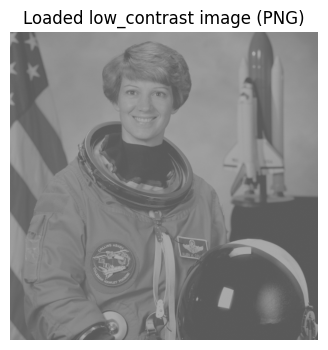

low_contrast image loaded from /content/drive/MyDrive/Computer_Vision/Lec1/low_contrast_image.png


In [ ]:
import cv2

# Define the path to load the image from Google Drive (ensure it matches the saving path)
save_path = '/content/drive/MyDrive/Computer_Vision/Lec1/low_contrast_image.png'

# Load the image back from Google Drive as grayscale
low_contrast = cv2.imread(save_path, cv2.IMREAD_GRAYSCALE)

# Display the loaded image to verify
plt.figure(figsize=(4, 4))
plt.imshow(low_contrast, cmap='gray', vmin=0, vmax=255)
plt.title('Loaded low_contrast image (PNG)')
plt.axis('off')
plt.show()
print(f'low_contrast image loaded from {save_path}')

In [ ]:
# TODO -- demonstrate global histogram equalization.
# Apply cv2.equalizeHist to the loaded low-contrast image. Then plot a 2x2
# panel: top row = low-contrast image + its histogram, bottom row = equalized
# image + its histogram. The equalized histogram should be spread across the
# full 0..255 range.

equalized = cv2.equalizeHist(low_contrast)            # cv2.equalizeHist(low_contrast)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0,0].imshow(low_contrast, cmap="gray", vmin=0, vmax=255)
axes[0,0].set_title("LOW-contrast image"); axes[0,0].axis("off")
axes[0,1].hist(low_contrast.ravel(), bins=256, range=(0, 255), color="steelblue")
axes[0,1].set_title("its histogram — narrow, bunched up")
axes[0,1].set_xlabel("intensity"); axes[0,1].set_ylabel("pixel count")

axes[1,0].imshow(equalized, cmap="gray", vmin=0, vmax=255)
axes[1,0].set_title("after histogram equalization"); axes[1,0].axis("off")
axes[1,1].hist(equalized.ravel(), bins=256, range=(0, 255), color="seagreen")
axes[1,1].set_title("its histogram — spread across the full range")
axes[1,1].set_xlabel("intensity"); axes[1,1].set_ylabel("pixel count")
plt.tight_layout(); plt.show()


### TODO 11.1
Global histogram equalization has a real-world weakness: it equalizes using the
*whole* image's histogram, so a locally dark region in an otherwise bright photo
stays dark. The fix used in practice is **CLAHE** (Contrast Limited Adaptive
Histogram Equalization), which equalizes small tiles independently.

Apply both `cv2.equalizeHist` and `cv2.createCLAHE` to the **original `gray`**
image (not the low-contrast one — `gray` already has both bright and dark
regions). Display original / global-equalized / CLAHE side by side and comment
on where CLAHE looks better and what its "contrast limit" is for.


In [ ]:
# TODO 11.1 -- global equalization vs adaptive (CLAHE) equalization.
# Apply BOTH to the ORIGINAL `gray` image (not the low-contrast one).
global_eq = cv2.equalizeHist(gray)

# CLAHE: build the operator first, then call .apply() on the image.
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
clahe_eq = clahe.apply(gray)         # apply clahe to `gray`

fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))
axes[0].imshow(gray,      cmap="gray", vmin=0, vmax=255); axes[0].set_title("original")
axes[1].imshow(global_eq, cmap="gray", vmin=0, vmax=255); axes[1].set_title("global equalizeHist")
axes[2].imshow(clahe_eq,  cmap="gray", vmin=0, vmax=255); axes[2].set_title("CLAHE (adaptive)")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

# Written answer (in this comment): where does CLAHE look better than global
# equalization? What is the `clipLimit` (contrast limit) protecting against?
#  -> CLAHE looks better in locally dark or bright regions that global equalisation over-brightens
#     or crushes. The clipLimit caps the slope of the tile CDF, preventing over-amplification of noise
#     in near-uniform (flat) regions -- without it a uniform patch would be stretched wildly.
